In [143]:
import sys
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from apatools.lm import lm, lm_report, mlm_icc, r_sq
from apatools.format import format_p, get_stars
import statsmodels.formula.api as smf
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [151]:
def lr_test(formula, data, groups): # if p<0.05 then use random effects
    '''likelihood ratio test of random-effects'''
    null_model = smf.mixedlm(formula, data=data, groups=groups, missing='drop').fit(reml=False)
    ols_model = smf.ols(formula, data=data).fit()
    lrt = np.abs(null_model.llf - ols_model.llf) * 2
    p = stats.chi2.sf(lrt, 1)
    return (lrt, p)

def ks_2samp_perm(full, subset, alternative='two-sided', n_perm=1000, seed=13):
    """
    K-S test with permutation p-value:
    Null hypothesis:
        The subset is a random sample from the full dataset.
    `two-sided` alternative: 
        p-value = probability of observing a KS statistic
        that is ether larger or smaller than expected by chance,
        having a sample of the same size. 
        p-value > 0.05 = The subset looks consistent with being a random draw 
        from the full sample (similar to the original stats.ks_2samp test.).
    `less` alternative: 
        p-value = probability of observing a KS statistic
        that is smaller than expected by chance. This means that
        the subset distribution is more similar to the full sample distribution 
        than expected by chance.
    `greater` alternative: 
        p-value = probability of observing a KS statistic
        that is larger than expected by chance. This means that
        the subset distribution is less similar to the full sample distribution 
        than expected by chance.
    """
    observed_stat, observed_p = stats.ks_2samp(subset, full)
    # print(f"observed_stat: {observed_stat:.3f}", f"observed_p: {_:.3f}")
    combined = np.array(full)
    perm_stats = []
    np.random.seed(seed)
    for _ in range(n_perm):
        perm_subset = np.random.permutation(combined)[:len(subset)]
        stat, _ = stats.ks_2samp(perm_subset, combined)
        perm_stats.append(stat)
        
    #p_value = (np.sum(perm_stats >= observed_stat) + 1) / (n_perm + 1) 
    #print('perm_stats >= observed_stat : more similar than random')
    #print(f"perm_stat: {np.mean(perm_stats):.3f}", f"perm_p: {p_value:.3f}")

    #p_value = (np.sum(perm_stats <= observed_stat) + 1) / (n_perm + 1) 
    #print('perm_stats <= observed_stat : less similar than random')
    #print(f"perm_stat: {np.mean(perm_stats):.3f}", f"perm_p: {p_value:.3f}")   
    
    p_upper = (np.sum(perm_stats > observed_stat) + 1) / (n_perm + 1)
    p_lower = (np.sum(perm_stats < observed_stat) + 1) / (n_perm + 1)
    if alternative == "less":
        return observed_stat, p_upper, observed_p
    elif alternative == "greater":
        return observed_stat, p_lower, observed_p
    p_value = np.clip(2 * min(p_upper, p_lower), 0.0, 1.0)
    return observed_stat, p_value, observed_p

def add_ks(a, b, ax):
    s, p, _ = ks_2samp_perm(a, b)
    hs, ls = ax.get_legend_handles_labels()
    rl = Line2D(
        [0],
        [0],
        marker="o",
        color="gray",
        markerfacecolor="white",
        markersize=6,
        linewidth=0.0,
    )
    return hs + [rl], ls + [
        "${KS}_{stat.} = " + f"{s:.2f}" + "^{" + get_stars(p) + "}$".replace('*', '{\\ast}')
    ]

In [3]:
base_dir = './'
results_dir = os.path.join(base_dir, "results")
data_dir = os.path.join(base_dir, "data")

In [194]:
df = pd.read_csv(os.path.join(results_dir, "data.csv"), index_col=0)
print(f"N={len(df)}")
s = "mean_shared_capacity"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "mean_degree"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "lifetime"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")

n = (df["mean_shared_capacity"] > 0) &\
    (df["mean_degree"] > 0) &\
    (df["lifetime"] > 0)

print(f"\nRemove nodes with zero capacity, lifetime or degree (n={len(df[~n])}, {len(df[~n])/len(df)*100:.2f}%):")
df = df[n]
print(f"N={len(df)}")
s = "mean_shared_capacity"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "mean_degree"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")
s = "lifetime"
n = (df[s] == 0).sum()
print(f"{s} == 0: n={n}, {n/len(df)*100:.2f}%")

results = {}
df.head()

N=39159
mean_shared_capacity == 0: n=2586, 6.60%
mean_degree == 0: n=693, 1.77%
lifetime == 0: n=709, 1.81%

Remove nodes with zero capacity, lifetime or degree (n=3678, 9.39%):
N=35481
mean_shared_capacity == 0: n=0, 0.00%
mean_degree == 0: n=0, 0.00%
lifetime == 0: n=0, 0.00%


,mean_shared_capacity,lifetime,mean_degree,region,country,latitude,longitude,log_mean_degree,log_lifetime,log_mean_shared_capacity,gdp_cap,log_gdp_cap
0,1.292802e+07,42,15.750000,Bavaria,DE,49.4542,11.0775,1.224015,1.633468,7.111532,43961.056336,4.643078
1,1.000000e+05,98,2.000000,NaN,NaN,NaN,NaN,0.477121,1.995635,5.000004,NaN,NaN
2,2.218966e+05,145,1.724138,NaN,NaN,NaN,NaN,0.435229,2.164353,5.346153,NaN,NaN
3,3.939878e+07,509,34.150000,Uusimaa,FI,60.1695,24.9354,1.545925,2.707570,7.595483,45550.955048,4.658507
4,3.077402e+06,1596,23.651613,Grand Est,FR,48.5839,7.7455,1.391845,3.203305,6.488184,38126.602922,4.581240


### Distribution analysis

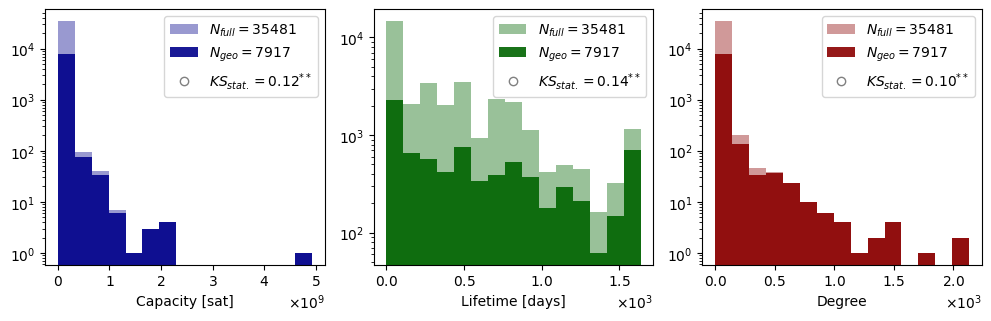

In [191]:
d = df.copy()
fig = plt.figure(figsize=(10, 3.3))
ax_left = fig.add_subplot(1, 3, 1)

s = "mean_shared_capacity"
d0 = d[s]
d0.hist(ax=ax_left, bins=15, label=f"$N_{{full}}={len(d0)}$", 
            log=True, color='darkblue', grid=False, alpha=0.4)
d1 = d.dropna(subset="country")[s]
d1.hist(ax=ax_left, bins=15, label=f"$N_{{geo}}={len(d1)}$", 
                  log=True, color='darkblue', grid=False, alpha=0.9)
h, l = add_ks(d0, d1, ax_left)
ax_left.legend(h, l, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_left.xaxis.set_major_formatter(xfmt)
ax_left.set_xlabel("Capacity [sat]")

ax_center = fig.add_subplot(1, 3, 2)
s = "lifetime"
d0 = d[s]
d0.hist(ax=ax_center, bins=15, label=f"$N_{{full}}={len(d0)}$", 
            log=True, color='darkgreen', grid=False, alpha=0.4)
d1 = d.dropna(subset="country")[s]
d1.hist(ax=ax_center, bins=15, label=f"$N_{{geo}}={len(d1)}$", 
                  log=True, color='darkgreen', grid=False, alpha=0.9)
h, l = add_ks(d0, d1, ax_center)
ax_center.legend(h, l, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_center.xaxis.set_major_formatter(xfmt)
ax_center.set_xlabel("Lifetime [days]")

ax_right= fig.add_subplot(1, 3, 3)
s = "mean_degree"
d0 = d[s]
d0.hist(ax=ax_right, bins=15, label=f"$N_{{full}}={len(d0)}$", 
            log=True, color='darkred', grid=False, alpha=0.4)
d1 = d.dropna(subset="country")[s]
d1.hist(ax=ax_right, bins=15, label=f"$N_{{geo}}={len(d1)}$", 
                  log=True, color='darkred', grid=False, alpha=0.9)
h, l = add_ks(d0, d1, ax_right)
ax_right.legend(h, l, loc="upper right")
xfmt = ScalarFormatter(useMathText=True)
xfmt.set_powerlimits((0, 0))
ax_right.xaxis.set_major_formatter(xfmt)
ax_right.set_xlabel("Degree")

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig02.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )

### Correlation analysis

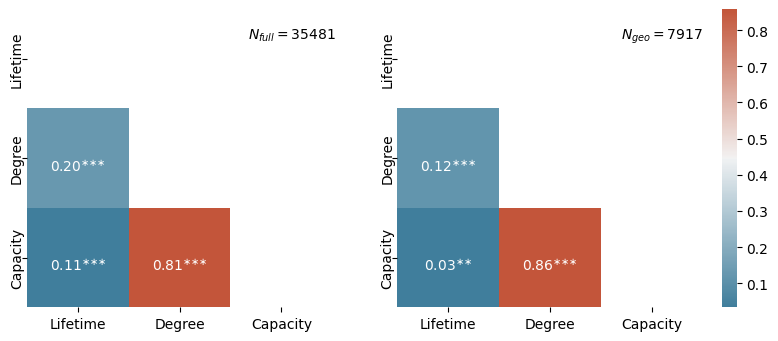

In [192]:
d = df.copy().rename(columns={
    "lifetime": "Lifetime",
    "mean_degree": "Degree",
    "mean_shared_capacity": "Capacity"})
fig = plt.figure(figsize=(8, 3.5))
ax_left = fig.add_subplot(1, 2, 1)
d0 = d[["Lifetime", "Degree", "Capacity"]]    
c = d0.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").statistic)
p = d0.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").pvalue)
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"{c[i][j]:.2f}$^{{{get_stars(p[i][j])}}}$".replace('*', '{\\ast}')
cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True) #cmap="YlGnBu"
mask = np.triu(np.ones_like(c, dtype=bool))
ax_left = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'top'}, fmt='', 
                 robust=False, ax=ax_left, cbar=True, annot=a)
ax_left.set_yticklabels(labels=ax_left.get_yticklabels(), ha='center', rotation=90)
ax_left.collections[0].colorbar.ax.set_visible(False)
ax_left.text(2.6, 0.3, f"$N_{{full}}={len(d0)}$", ha='center')

ax_right = fig.add_subplot(1, 2, 2)
d1 = d.dropna(subset="country")[["Lifetime", "Degree", "Capacity"]]    
c = d1.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").statistic)
p = d1.corr(method=lambda x, y: stats.spearmanr(x, y, nan_policy="omit").pvalue)
a = c.copy().astype(str)
for i in a.keys():
    for j in a[i].keys():
        a.loc[i, j] = f"{c[i][j]:.2f}$^{{{get_stars(p[i][j])}}}$".replace('*', '{\\ast}')
#cmap = sns.diverging_palette(230, 20, n=256, as_cmap=True)
mask = np.triu(np.ones_like(c, dtype=bool))
ax_right = sns.heatmap(c, cmap=cmap, mask=mask, annot_kws={'va':'top'}, fmt='', 
                 robust=False, ax=ax_right, cbar=True, annot=a) 
ax_right.set_yticklabels(labels=ax_right.get_yticklabels(), ha='center', rotation=90)
ax_right.text(2.6, 0.3, f"$N_{{geo}}={len(d1)}$", ha='center')

fig.tight_layout(pad=1.01)
fig.savefig(
        os.path.join(results_dir, "fig03.pdf"),
        dpi=1200,
        bbox_inches="tight",
        format='pdf',
    )


## Hypoteses

### H1 Lifetime → Capacity

In [91]:
# H1 Lifetime → Capacity (RLM) full_sample
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H1(RLM)+full'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=38450
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524BD6C00>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                38450
Model:                                  RLM   Df Residuals:                    38448
Method:                                IRLS   Df Model:                            1
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:11:55                                         
No. Iterations:                          12                     

'β=0.31***, 95%CI [0.28, 0.33]'

In [92]:
# H1 Lifetime → Capacity (RLM) geo_sample
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H1(RLM)+geo'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8854
formula: log_mean_shared_capacity ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5277AAA20>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8852
Method:                                IRLS   Df Model:                            1
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:12:26                                         
No. Iterations:                          26                      

'β=0.11***, 95%CI [0.06, 0.17]'

In [93]:
# H1 Lifetime → Capacity (RLM) geo_sample+country
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H1(RLM)+geo+country'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8854
formula: log_mean_shared_capacity ~ 1 + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5227F8B90>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8851
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:12:49                                         
No. Iterations:                          14            

'β=0.11***, 95%CI [0.06, 0.17]'

In [94]:
# H1 Lifetime → Capacity (RLM) geo_sample+gdp
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H1(RLM)+geo+gdp'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8828
formula: log_mean_shared_capacity ~ 1 + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524BC17F0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8828
Model:                                  RLM   Df Residuals:                     8825
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:13:13                                         
No. Iterations:                          26        

'β=0.11***, 95%CI [0.06, 0.17]'

In [95]:
# H1 Lifetime → Capacity (MLM) geo+country
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+country'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .03, R²adj = .03, F(1, 8853) = 252.98, p < .0001, AIC = 38462.1, BIC = 38490.4, LL = -19227.0,
N = 8854, G = 97, ICC = 0.02, LRTstat. = 112634.7 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8854    Method:             ML                      
No. Groups:       97      Scale:              4.4790                  
Min. group size:  1       Log-Likelihood:     -19227.0375             
Max. group size:  3034    Converged:          Yes                     
Mean group size:  91.3                                                
-------------------------------------------------------------------------
                 Coef.    Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        4.919       0.107    46.063    0.000     4.710     5.129
log_

'β=0.18***, 95%CI [0.11, 0.25]'

In [25]:
# H1 Lifetime → Capacity (MLM) geo_sample+country+region
f = "log_mean_shared_capacity ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+country+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .09, R²adj = .09, F(1, 8853) = 883.81, p < .0001, AIC = 37822.4, BIC = 37857.8, LL = -18906.2,
N = 8854, G = 97, ICC = 0.00, LRTstat. = 112634.7 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8854    Method:             ML                      
No. Groups:       97      Scale:              4.0788                  
Min. group size:  1       Log-Likelihood:     -18906.1768             
Max. group size:  3034    Converged:          Yes                     
Mean group size:  91.3                                                
-------------------------------------------------------------------------
                 Coef.    Std.Err.      z       P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept        4.774       0.101    47.083    0.000     4.575

'β=0.21***, 95%CI [0.14, 0.28]'

In [ ]:
# H1 Lifetime → Capacity (MLM) geo_sample+gdp
f = "log_mean_shared_capacity ~ log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+gdp'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .03, R²adj = .03, F(2, 8826) = 131.63, p < .0001, AIC = 38354.7, BIC = 38390.2, LL = -19172.4,
N = 8828, G = 97, ICC = 0.03, LRTstat. = 151.6 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + log_gdp_cap + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8828    Method:             ML                      
No. Groups:       90      Scale:              4.4810                  
Min. group size:  1       Log-Likelihood:     -19172.3627             
Max. group size:  3034    Converged:          Yes                     
Mean group size:  98.1                                                
-------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept         3.665       0.700    5.232    0.000     2.292    

'β=0.18***, 95%CI [0.11, 0.25]'

In [ ]:
# H1 Lifetime → Capacity (MLM) geo_sample+gdp+region
f = "log_mean_shared_capacity ~ log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H1(MLM)+geo+gdp+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .13, R²adj = .13, F(2, 8826) = 657.50, p < .0001, AIC = 37731.1, BIC = 37773.6, LL = -18859.6,
N = 8828, G = 97, ICC = 0.06, LRTstat. = 151.6 (p < .0001)
log_mean_shared_capacity ~ log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8828    Method:             ML                      
No. Groups:       90      Scale:              4.0742                  
Min. group size:  1       Log-Likelihood:     -18859.5664             
Max. group size:  3034    Converged:          No                      
Mean group size:  98.1                                                
-------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|    [0.025    0.975]
-------------------------------------------------------------------------
Intercept         3.693       0.890    4.148    0.00

'β=0.21***, 95%CI [0.14, 0.28]'

### H2-1 Lifetime → Degree

In [90]:
# H2-1 Lifetime → Degree (RLM) full_sample
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H21(RLM)+full'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=38450
formula: log_mean_degree ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5277A5310>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                38450
Model:                            RLM   Df Residuals:                    38448
Method:                          IRLS   Df Model:                            1
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 19 Mar 2026                                         
Time:                        19:10:45                                         
No. Iterations:                    13                                         
                   coef    std err          z   

'β=0.14***, 95%CI [0.14, 0.15]'

In [89]:
# H2-1 Lifetime → Degree (RLM) geo_sample
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H21(RLM)+geo'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8854
formula: log_mean_degree ~ 1 + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524E5E5D0>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 8854
Model:                            RLM   Df Residuals:                     8852
Method:                          IRLS   Df Model:                            1
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 19 Mar 2026                                         
Time:                        19:10:09                                         
No. Iterations:                    11                                         
                   coef    std err          z    

'β=0.07***, 95%CI [0.06, 0.09]'

In [88]:
# H2-1 Lifetime → Degree (RLM) geo_sample+country
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_degree", ["log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H21(RLM)+geo+country'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8854
formula: log_mean_degree ~ 1 + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5227F8B90>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 8854
Model:                            RLM   Df Residuals:                     8851
Method:                          IRLS   Df Model:                            2
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 19 Mar 2026                                         
Time:                        19:09:39                                         
No. Iterations:                    12                                         
                   coef    std err     

'β=0.07***, 95%CI [0.06, 0.09]'

In [87]:
# H2-1 Lifetime → Degree (RLM) geo_sample+gdp
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_degree", ["log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H21(RLM)+geo+gdp'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

N=8828
formula: log_mean_degree ~ 1 + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5277B3470>}
fit_kwargs: {}
                    Robust linear Model Regression Results                    
Dep. Variable:        log_mean_degree   No. Observations:                 8828
Model:                            RLM   Df Residuals:                     8825
Method:                          IRLS   Df Model:                            2
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Thu, 19 Mar 2026                                         
Time:                        19:09:09                                         
No. Iterations:                    16                                         
                   coef    std err 

'β=0.07***, 95%CI [0.06, 0.09]'

In [ ]:
# H2-1 Lifetime → Degree (MLM) geo_sample+country
f = "log_mean_degree ~ log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+country'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .07, R²adj = .07, F(1, 8853) = 619.59, p < .0001, AIC = 13471.5, BIC = 13499.9, LL = -6731.8,
N = 8854, G = 97, ICC = 0.05, LRTstat. = 29866.7 (p < .0001)
log_mean_degree ~ log_lifetime + (1 | country)  
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 8854    Method:             ML             
No. Groups:       97      Scale:              0.2655         
Min. group size:  1       Log-Likelihood:     -6731.7658     
Max. group size:  3034    Converged:          Yes            
Mean group size:  91.3                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.728     0.029  25.435  0.000   0.672   0.784
log_lifetime    0.098     0.009  11.368  0.000   0.081   0.115
Group Var       0.015     0.008                       

'β=0.10***, 95%CI [0.08, 0.12]'

In [ ]:
# H2-1 Lifetime → Degree (MLM) geo_sample+country+region
f = "log_mean_degree ~ log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+country+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .09, R²adj = .09, F(1, 8853) = 917.04, p < .0001, AIC = 12995.5, BIC = 13030.9, LL = -6492.7,
N = 8854, G = 97, ICC = 0.00, LRTstat. = 29866.7 (p < .0001)
log_mean_degree ~ log_lifetime + (1 | country)  +  (1 | region)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 8854    Method:             ML             
No. Groups:       97      Scale:              0.2476         
Min. group size:  1       Log-Likelihood:     -6492.7349     
Max. group size:  3034    Converged:          Yes            
Mean group size:  91.3                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.693     0.025  27.373  0.000   0.643   0.742
log_lifetime    0.111     0.008  13.129  0.000   0.094   0.127
Group Var       0.001     0.003        

'β=0.11***, 95%CI [0.09, 0.13]'

In [30]:
# H2-1 Lifetime → Degree (MLM) geo_sample+gdp
f = "log_mean_degree ~ log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+gdp'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .07, R²adj = .07, F(2, 8826) = 310.75, p < .0001, AIC = 13437.5, BIC = 13472.9, LL = -6713.7,
N = 8828, G = 97, ICC = 0.05, LRTstat. = 378.7 (p < .0001)
log_mean_degree ~ log_lifetime + log_gdp_cap + (1 | country)  
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 8828    Method:             ML             
No. Groups:       90      Scale:              0.2657         
Min. group size:  1       Log-Likelihood:     -6713.7375     
Max. group size:  3034    Converged:          Yes            
Mean group size:  98.1                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.408     0.201   2.035  0.042   0.015   0.802
log_lifetime    0.098     0.009  11.315  0.000   0.081   0.115
log_gdp_cap     0.074     0.046   1.620  0

'β=0.10***, 95%CI [0.08, 0.12]'

In [31]:
# H2-1 Lifetime → Degree (MLM) geo_sample+gdp+region
f = "log_mean_degree ~ log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H21(MLM)+geo+gdp+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .10, R²adj = .10, F(2, 8826) = 467.85, p < .0001, AIC = 12962.5, BIC = 13005.0, LL = -6475.3,
N = 8828, G = 97, ICC = 0.01, LRTstat. = 378.7 (p < .0001)
log_mean_degree ~ log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_degree
No. Observations: 8828    Method:             ML             
No. Groups:       90      Scale:              0.2476         
Min. group size:  1       Log-Likelihood:     -6475.2515     
Max. group size:  3034    Converged:          Yes            
Mean group size:  98.1                                       
--------------------------------------------------------------
                Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.468     0.176   2.659  0.008   0.123   0.813
log_lifetime    0.111     0.008  13.091  0.000   0.094   0.127
log_gdp_cap     0.051     0

'β=0.11***, 95%CI [0.09, 0.13]'

### H2-2 Degree → Capacity (controlling for Lifetime)

In [83]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) full_sample
d = df.copy()
d = d[d['lifetime'] > 0]
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H22(RLM)+full'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=38450
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5277ABF80>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                38450
Model:                                  RLM   Df Residuals:                    38447
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:06:33                                         
No. Iterations:                          37   

'β=2.23***, 95%CI [2.22, 2.25]'

In [84]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime",], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H22(RLM)+geo'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8854
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524E33C20>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8851
Method:                                IRLS   Df Model:                            2
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:06:59                                         
No. Iterations:                          44    

'β=2.05***, 95%CI [2.03, 2.08]'

In [85]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+country
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H22(RLM)+geo+country'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8854
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524E61DC0>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8850
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:07:42                                         
No. Iterations:                      

'β=2.05***, 95%CI [2.02, 2.08]'

In [86]:
# H2-2 Degree → Capacity (controlling for Lifetime) (RLM) geo_sample+gdp
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
m, i = lm(d, "log_mean_shared_capacity", ["log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H22(RLM)+geo+gdp'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8828
formula: log_mean_shared_capacity ~ 1 + log_mean_degree + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D524F4F050>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8828
Model:                                  RLM   Df Residuals:                     8824
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:08:15                                         
No. Iterations:                  

'β=2.06***, 95%CI [2.03, 2.08]'

In [39]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+country
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+country'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .40, R²adj = .40, F(2, 8852) = 2978.96, p < .0001, AIC = 34141.4, BIC = 34176.9, LL = -17065.7,
N = 8854, G = 97, ICC = 0.01, LRTstat. = 96071.0 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8854    Method:             ML                      
No. Groups:       97      Scale:              2.7544                  
Min. group size:  1       Log-Likelihood:     -17065.7088             
Max. group size:  3034    Converged:          Yes                     
Mean group size:  91.3                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            3.077      0.083   37.225   0.000    2.915

'β=2.55***, 95%CI [2.48, 2.61]'

In [40]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+country+region
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+country+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .54, R²adj = .54, F(2, 8852) = 5184.72, p < .0001, AIC = 33673.7, BIC = 33716.2, LL = -16830.8,
N = 8854, G = 97, ICC = 0.22, LRTstat. = 96071.0 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8854    Method:             ML                      
No. Groups:       97      Scale:              2.4940                  
Min. group size:  1       Log-Likelihood:     -16830.8423             
Max. group size:  3034    Converged:          No                      
Mean group size:  91.3                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            3.043      0.136   22.455  

'β=2.50***, 95%CI [2.44, 2.57]'

In [41]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+gdp
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+gdp'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .40, R²adj = .40, F(3, 8825) = 1976.68, p < .0001, AIC = 34053.8, BIC = 34096.3, LL = -17020.9,
N = 8828, G = 97, ICC = 0.01, LRTstat. = 100.2 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap + (1 | country)  
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8828    Method:             ML                      
No. Groups:       90      Scale:              2.7578                  
Min. group size:  1       Log-Likelihood:     -17020.8834             
Max. group size:  3034    Converged:          Yes                     
Mean group size:  98.1                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            2.583      0.480    5.382   0.

'β=2.54***, 95%CI [2.48, 2.61]'

In [ ]:
# H2-2 Degree → Capacity (controlling for Lifetime)  (MLM) geo+gdp+region
f = "log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H22(MLM)+geo+gdp+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[1]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .54, R²adj = .54, F(3, 8825) = 3504.14, p < .0001, AIC = 33585.2, BIC = 33634.8, LL = -16785.6,
N = 8828, G = 97, ICC = 0.23, LRTstat. = 100.2 (p < .0001)
log_mean_shared_capacity ~ log_mean_degree + log_lifetime + log_gdp_cap + (1 | country)  +  (1 | region)
                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations: 8828    Method:             ML                      
No. Groups:       90      Scale:              2.4972                  
Min. group size:  1       Log-Likelihood:     -16785.6014             
Max. group size:  3034    Converged:          No                      
Mean group size:  98.1                                                
------------------------------------------------------------------------
                    Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
------------------------------------------------------------------------
Intercept            2.703      1.12

'β=2.50***, 95%CI [2.43, 2.57]'

### H3 Lifetime × Degree → Capacity

In [81]:
# H3 Lifetime × Degree → Capacity (RLM) full
d = df.copy()
d = d[d['lifetime'] > 0]
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H3(RLM)+full'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"



N=38450
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D52561B770>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                38450
Model:                                  RLM   Df Residuals:                    38446
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:04:26                                         
No. Iterations:             

'β=-0.04**, 95%CI [-0.06, -0.01]'

In [80]:
# H3 Lifetime × Degree → Capacity (RLM) geo
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H3(RLM)+geo'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8854
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5227F8B00>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8850
Method:                                IRLS   Df Model:                            3
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:03:21                                         
No. Iterations:              

'β=0.05*, 95%CI [0.00, 0.09]'

In [78]:
# H3 Lifetime × Degree → Capacity (RLM) geo+country
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d["country"] = d["country"].astype("category").cat.codes
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "country"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H3(RLM)+geo+country'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8854
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + country
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5228A4560>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8854
Model:                                  RLM   Df Residuals:                     8849
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:02:48                                         
No. Iterations:    

'β=0.05*, 95%CI [0.00, 0.09]'

In [76]:
# H3 Lifetime × Degree → Capacity (RLM) geo+gdp
d = df.copy()
d = d[d['lifetime'] > 0].dropna(subset='country')
d['lifetimeXdegree'] = d['log_lifetime'] * d['log_mean_degree']
m, i = lm(d, "log_mean_shared_capacity", ["lifetimeXdegree", "log_mean_degree", "log_lifetime", "log_gdp_cap"], model = 'rlm',
                                    verbose = True,
                                    constant = True,
                                    standardized = False,
                                    r_sq = True,
                                    pred_r_sq = False,
                                    rlm_model_M = sm.robust.norms.Hampel())
r = lm_report(m, i)[0]
b = r.iloc[1]
r = r.iloc[0]
results['H3(RLM)+geo+gdp'] = r
print(r['model'])
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"


N=8828
formula: log_mean_shared_capacity ~ 1 + lifetimeXdegree + log_mean_degree + log_lifetime + log_gdp_cap
model: RLM
model_kwargs: {'M': <statsmodels.robust.norms.Hampel object at 0x000002D5227CB890>}
fit_kwargs: {}
                       Robust linear Model Regression Results                       
Dep. Variable:     log_mean_shared_capacity   No. Observations:                 8828
Model:                                  RLM   Df Residuals:                     8823
Method:                                IRLS   Df Model:                            4
Norm:                                Hampel                                         
Scale Est.:                             mad                                         
Cov Type:                                H1                                         
Date:                      Thu, 19 Mar 2026                                         
Time:                              19:02:14                                         
No. Iterations:

'β=0.05*, 95%CI [0.00, 0.09]'

In [ ]:
# H3 Lifetime × Degree → Capacity (MLM) geo+country
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+country'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .40, R²adj = .40, F(3, 8851) = 1995.39, p < .0001, AIC = 34128.1, BIC = 34170.6, LL = -17058.1,
N = 8854, G = 97, ICC = 0.01, LRTstat. = 96062.6 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + (1 | country)  
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  8854    Method:             ML                      
No. Groups:        97      Scale:              2.7496                  
Min. group size:   1       Log-Likelihood:     -17058.0559             
Max. group size:   3034    Converged:          Yes                     
Mean group size:   91.3                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.548    0.146 24.304 0.000  

'β=0.21***, 95%CI [0.11, 0.32]'

In [66]:
# H3 Lifetime × Degree → Capacity (MLM) geo+country+region
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+country+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .44, R²adj = .44, F(3, 8851) = 2274.31, p < .0001, AIC = 33548.0, BIC = 33597.6, LL = -16767.0,
N = 8854, G = 97, ICC = 0.00, LRTstat. = 96062.6 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + (1 | country)  +  (1 | region)
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  8854    Method:             ML                      
No. Groups:        97      Scale:              2.5290                  
Min. group size:   1       Log-Likelihood:     -16767.0006             
Max. group size:   3034    Converged:          Yes                     
Mean group size:   91.3                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.583    0.142

'β=0.24***, 95%CI [0.14, 0.35]'

In [68]:
# H3 Lifetime × Degree → Capacity (MLM) geo+gdp
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap"
vc = {}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+gdp'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .40, R²adj = .40, F(4, 8824) = 1489.34, p < .0001, AIC = 34040.8, BIC = 34090.4, LL = -17013.4,
N = 8828, G = 97, ICC = 0.01, LRTstat. = 100.0 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap + (1 | country)  
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  8828    Method:             ML                      
No. Groups:        90      Scale:              2.7531                  
Min. group size:   1       Log-Likelihood:     -17013.4186             
Max. group size:   3034    Converged:          Yes                     
Mean group size:   98.1                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.055    0.495  6

'β=0.21***, 95%CI [0.10, 0.32]'

In [ ]:
# H3 Lifetime × Degree → Capacity (MLM) geo+gdp+region
f = "log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap"
vc = {"region": "0 + C(region)",}
d = df.copy()
d = d[d['lifetime'] > 0]
m = smf.mixedlm(f, d, groups=d["country"], re_formula="1", vc_formula=vc, 
                missing='drop').fit(reml=False)
lrt, p = lr_test(f, d, d["country"])
ricc = mlm_icc(m)
i = r_sq(m)
b = lm_report([m], [i])[0]
r = b.iloc[0]
r['model'] += f",\nN = {i['n_obs']}, G = {len(set(df.dropna(subset=['country'])['country']))}"
r['model'] += f', ICC = {ricc:.2f}, LRTstat. = {lrt:.1f} ({format_p(p)})'
results['H3(MLM)+geo+gdp+region'] = r
print(r['model'])
print(f, '+ (1 | country)', ' + ' if len(vc) else '', ' + '.join([f"(1 | {k})" for k in vc.keys()]))
print(m.summary())
b = b.iloc[3]
f"β={b['coef']:.2f}{b['sig']}, 95%CI [{b['cil']:.2f}, {b['cir']:.2f}]"

R² = .55, R²adj = .55, F(4, 8824) = 2645.10, p < .0001, AIC = 33566.9, BIC = 33623.6, LL = -16775.5,
N = 8828, G = 97, ICC = 0.23, LRTstat. = 100.0 (p < .0001)
log_mean_shared_capacity ~ log_lifetime * log_mean_degree + log_gdp_cap + (1 | country)  +  (1 | region)
                 Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_mean_shared_capacity
No. Observations:  8828    Method:             ML                      
No. Groups:        90      Scale:              2.4910                  
Min. group size:   1       Log-Likelihood:     -16775.4647             
Max. group size:   3034    Converged:          No                      
Mean group size:   98.1                                                
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.

'β=0.24***, 95%CI [0.14, 0.34]'

### Tables & Figures